<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Time_Value_of_Money_(TVM)_Analytics_%26_Investment_Growth_Forecasting_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn yfinance scikit-learn xgboost fredapi

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [ ]:
ticker = 'JPM'

df = yf.download(
    ticker,
    start = '2020-01-01',
    end = '2026-05-01'
)

[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2020-01-02,118.430351,118.438753,116.894255,117.339134,10803700
2020-01-03,116.867477,117.619335,115.803054,116.157862,10386800
2020-01-06,116.774529,116.808327,115.313055,115.363740,10259000
2020-01-07,114.789291,116.461961,114.738606,115.971984,10531300
2020-01-08,115.684799,116.225461,114.552791,114.637262,9695300


In [ ]:
np.random.seed(42)

investment_data = pd.DataFrame({
    'Present_Value':np.random.randint(
        1000,
        100000,
        1000
    ),

    'Interest_rate': np.random.uniform(
        0.01,
        0.15,
        1000
    ),

    'Years': np.random.randint(
        1,
        20,
        1000
    )
})

In [ ]:
#Calculate Future Value
investment_data['Future_Value'] = (
    investment_data['Present_Value']
    *
    (1 + investment_data['Interest_rate'])
    **
    investment_data['Years']
)

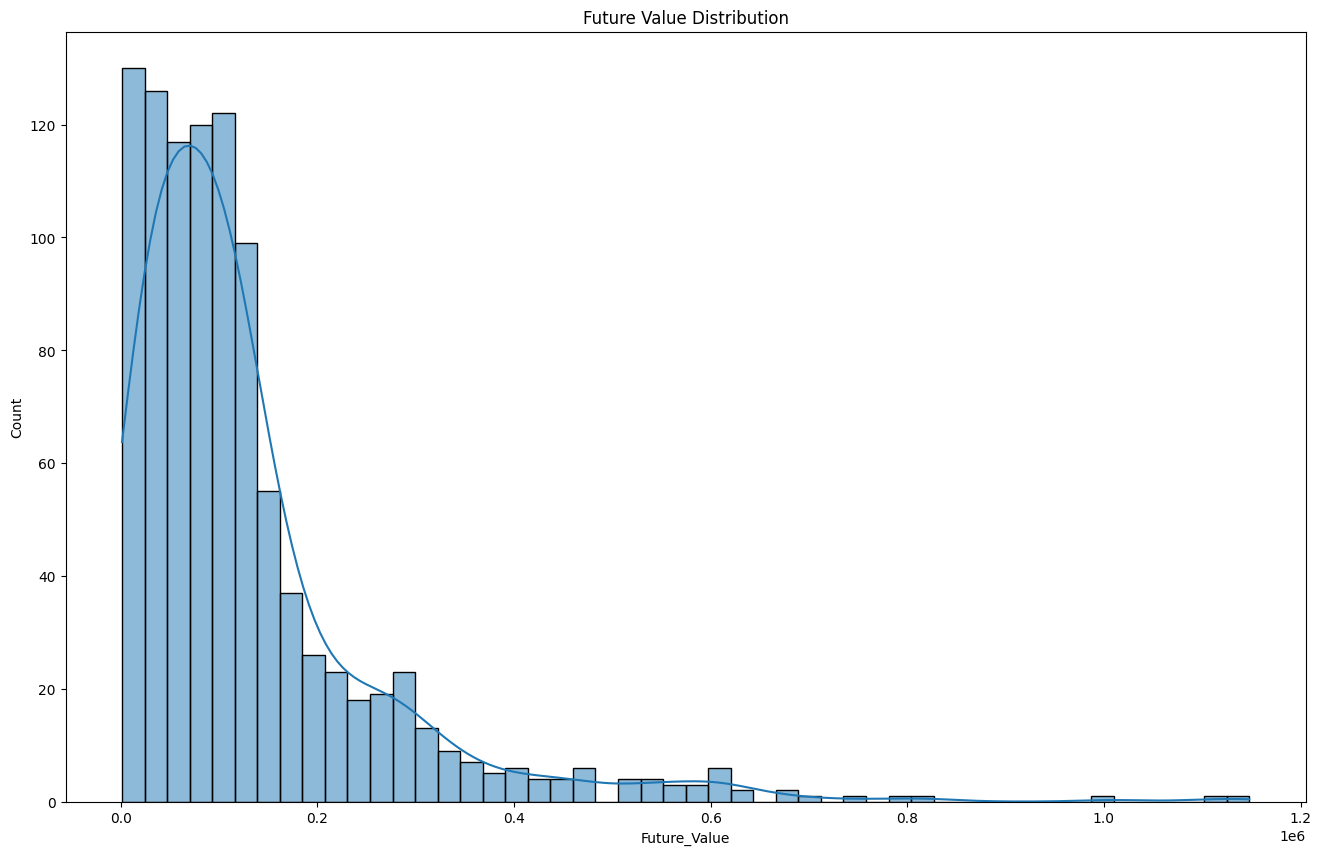

In [ ]:
plt.figure(figsize=(16,10))

sns.histplot(
    investment_data['Future_Value'],
    bins = 50,
    kde = True
)

plt.title('Future Value Distribution')
plt.show()

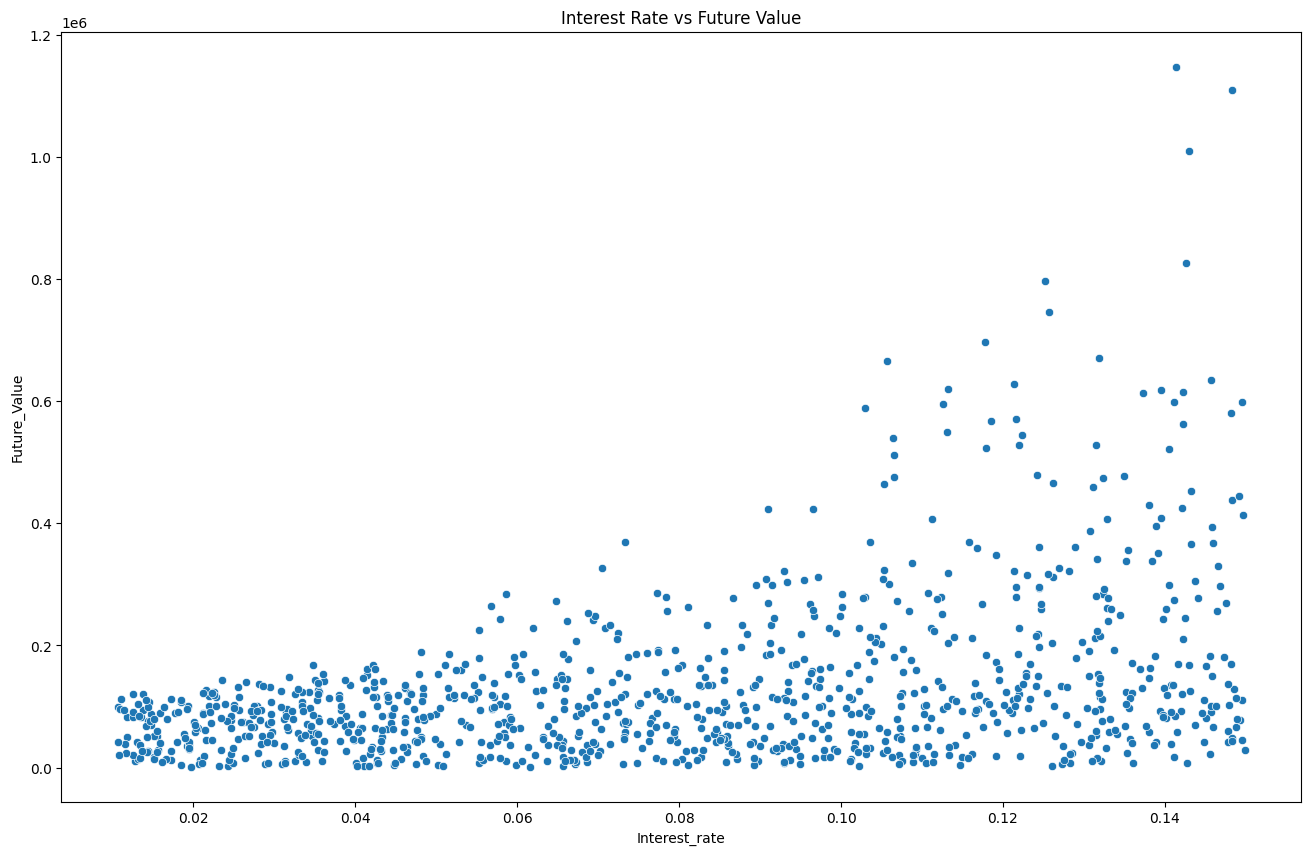

In [ ]:
plt.figure(figsize=(16,10))

sns.scatterplot(
    x = 'Interest_rate',
    y = 'Future_Value',
    data = investment_data
)

plt.title('Interest Rate vs Future Value')
plt.show()

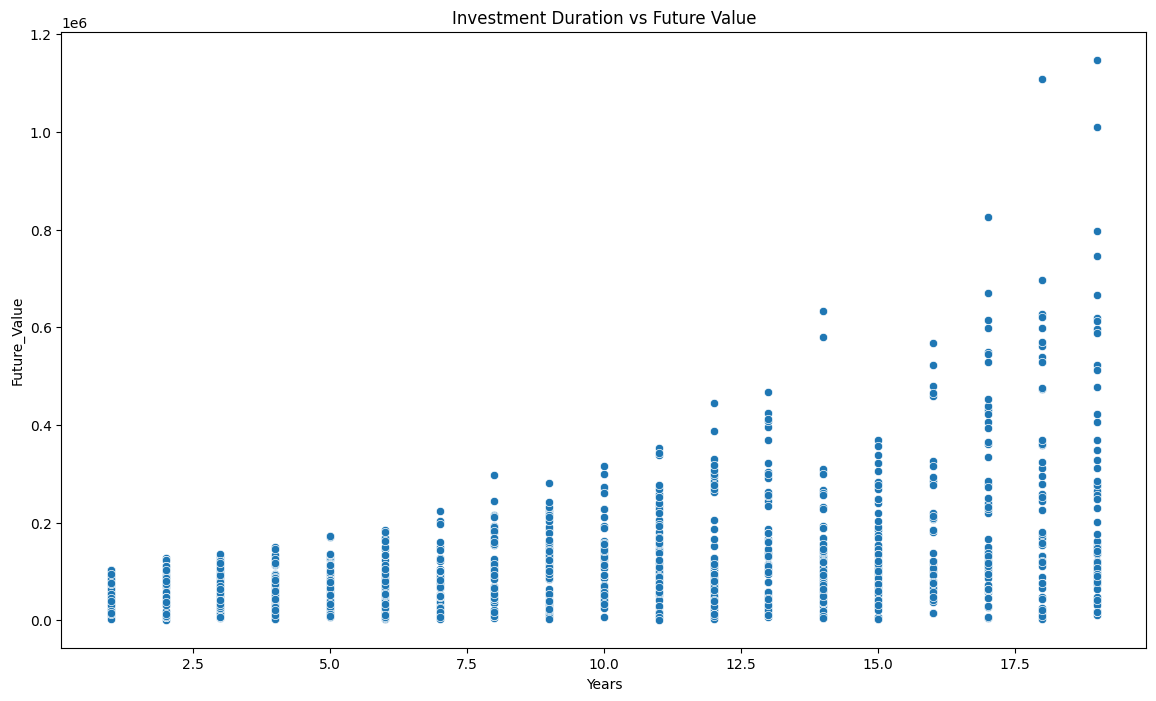

In [ ]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    x = 'Years',
    y = 'Future_Value',
    data = investment_data
)

plt.title('Investment Duration vs Future Value')
plt.show()

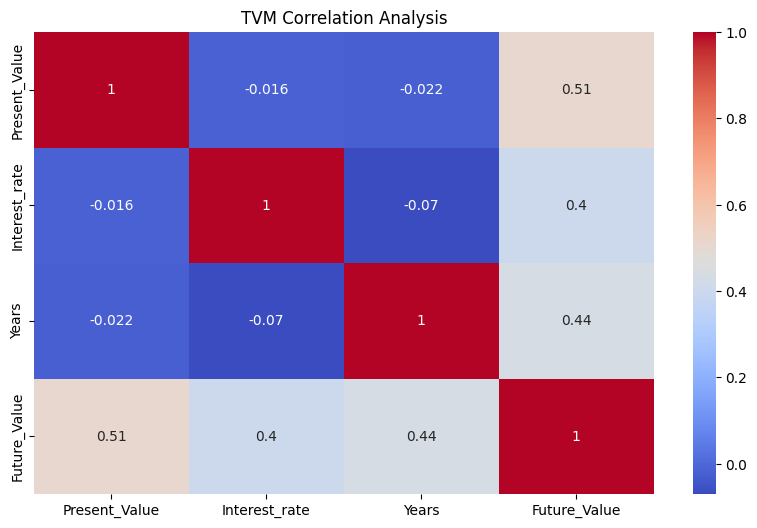

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    investment_data.corr(),
    annot = True,
    cmap = 'coolwarm'
)

plt.title('TVM Correlation Analysis')
plt.show()

In [ ]:
X = investment_data[
    [
        'Present_Value',
        'Interest_rate',
        'Years'
    ]
]

y = investment_data['Future_Value']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [ ]:
rf = RandomForestRegressor(
    n_estimators = 300,
    random_state=42
)

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [ ]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [ ]:
def evaluate(y_true, pred, model):

    print(f"\n{model}")

    print(
        "MAE:",
        mean_absolute_error(y_true, pred)
    )

    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, pred))
    )

    print(
        "R2:",
        r2_score(y_true, pred)
    )

In [ ]:
evaluate(y_test, lr_pred, 'Linear Regression')

evaluate(y_test, rf_pred, 'Random Forest')

evaluate(y_test, xgb_pred, 'XGBoost')


Linear Regression
MAE: 57920.38745798143
RMSE: 94056.04415373088
R2: 0.6404559348932377

Random Forest
MAE: 10669.086004046207
RMSE: 25589.692844110607
R2: 0.9733860796795659

XGBoost
MAE: 9910.047845513736
RMSE: 24043.60960294333
R2: 0.9765048597594663


###Linear Regression was unable to fully capture the exponential compounding behavior inherent in Time Value of Money calculations

###Random Forest effectively modeled the non-linear impact of interest rates and investment duration on future investment value.

###The machine learning models identified investment duration and interest rates as the primary drivers of future investment growth. Tree-based ensemble methods significantly outperformed Linear Regression due to their ability to capture exponential compounding behavior and non-linear financial relationships.

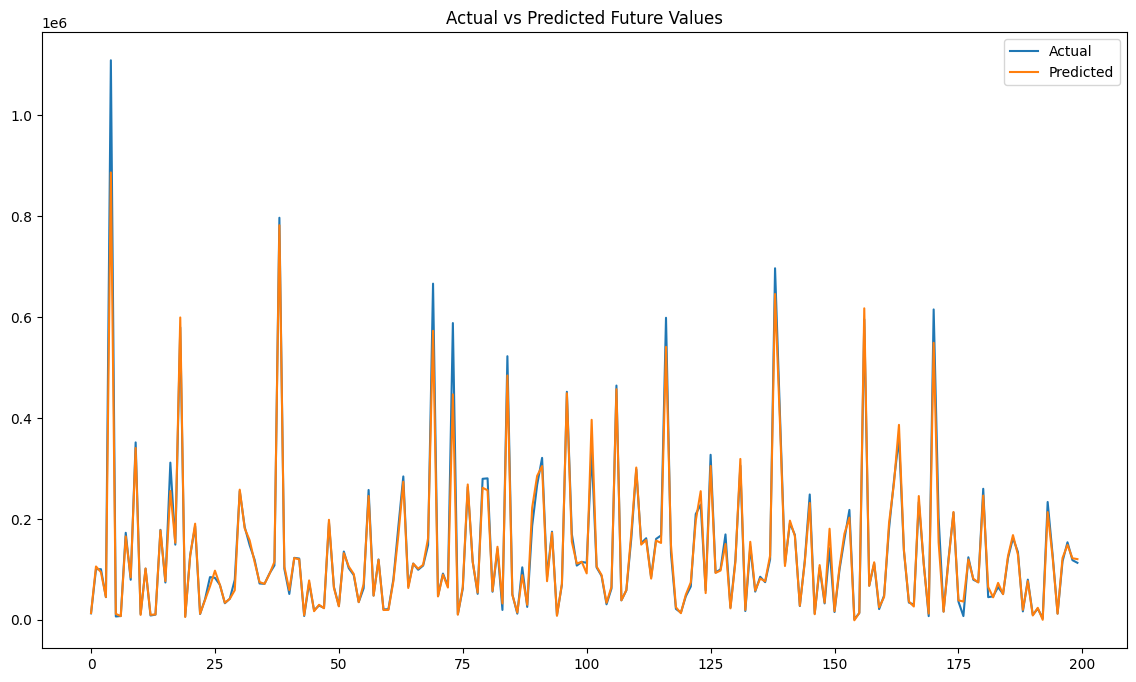

In [ ]:
plt.figure(figsize=(14,8))

plt.plot(
    y_test.values,
    label = 'Actual'
)

plt.plot(
    xgb_pred,
    label = 'Predicted'
)

plt.legend()
plt.title('Actual vs Predicted Future Values')
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

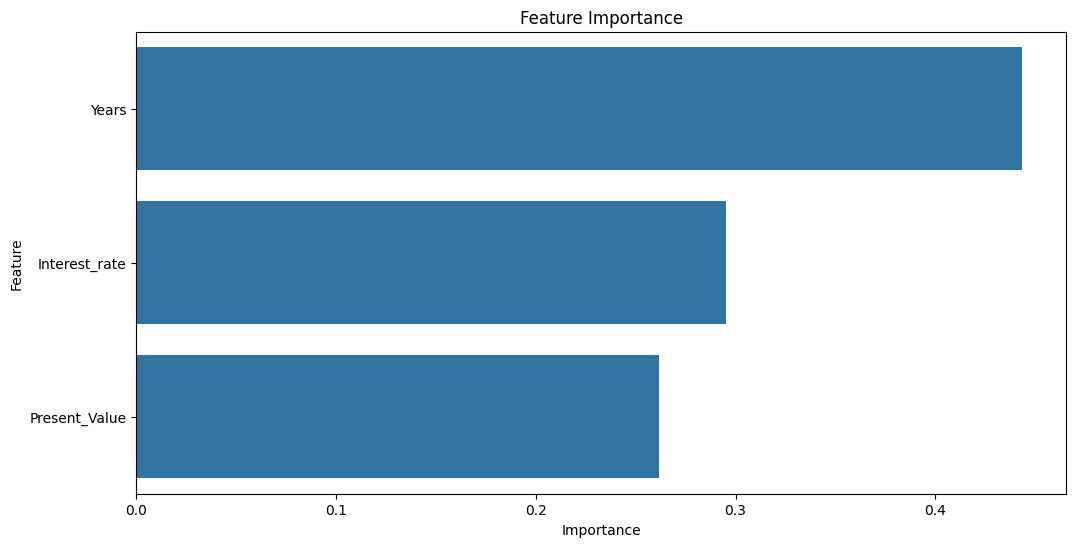

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.show()

###Years, Interest rates showing highest importance,

###it means:

###Long-term investing and compounding are major wealth creation drivers.